In [ ]:
!pip install --upgrade torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as transforms
from google.colab import drive
from sklearn.model_selection import train_test_split
from torchvision.transforms.v2 import InterpolationMode
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 나눔 폰트 설치
!apt-get -qq -y install fonts-nanum > /dev/null
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rc('font', family='NanumBarunGothic')
plt.rc('axes', unicode_minus=False)

# 2. 구글 드라이브 마운트
drive.mount('/content/drive')

# 3. 데이터 파일 경로 설정 및 로드
file_path = '/content/drive/MyDrive/ACK2026_Wafer/MIR-WM811K/MIR-WM811K/Python/WM811K_defects.pkl'
print("🔄 데이터셋 로드 중...")
df_defects = pd.read_pickle(file_path)
print(f"✅ 데이터 로드 완료! 총 {len(df_defects)}개")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 데이터셋 로드 중...
✅ 데이터 로드 완료! 총 25519개


In [ ]:
print("실제 데이터 라벨 목록:", df_defects['failureType'].unique())

실제 데이터 라벨 목록: ['Loc' 'Edge-Loc' 'Center' 'Edge-Ring' 'Scratch' 'Random' 'Near-full'
 'Donut']


In [ ]:
# 1. 최근방 이웃 보간법을 이용한 128x128 리사이징 함수
def preprocess_wafer_image(wafer_map, target_size=(128, 128)):
    resized_map = cv2.resize(wafer_map.astype(np.uint8), target_size, interpolation=cv2.INTER_NEAREST)
    return torch.tensor(resized_map, dtype=torch.long)

# 2. 기하학적 증강 정의
wafer_augmentor = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(
        degrees=(-180, 180),
        interpolation=InterpolationMode.NEAREST,
        fill=0  # 회전 후 생기는 모서리 빈 공간을 0(배경)으로 채움
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        interpolation=InterpolationMode.NEAREST,
        fill=0  # 이동 후 생기는 빈 공간을 0(배경)으로 채움
    )
])

# 3. PyTorch WaferDataset 클래스 정의
class WaferDataset(Dataset):
    def __init__(self, df, label_mapping, is_training=True, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_mapping = label_mapping
        self.is_training = is_training
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wafer_map = row['waferMap']
        label_str = row['failureType']
        label = self.label_mapping[label_str]

        # 128x128 리사이징
        tensor_map = preprocess_wafer_image(wafer_map, target_size=(128, 128)).unsqueeze(0)

        # 훈련 세트일 경우 기하학적 증강 적용
        if self.is_training and self.transform is not None:
            tensor_map = self.transform(tensor_map)

        # 3채널 원핫 인코딩 변환: [1, 128, 128] -> [3, 128, 128]
        tensor_map = tensor_map.squeeze(0)
        one_hot_map = F.one_hot(tensor_map, num_classes=3).permute(2, 0, 1).float()

        return one_hot_map, torch.tensor(label, dtype=torch.long)

# 4. 소수 클래스 균등화 함수 정의
def balance_training_dataset(train_df, target_samples_per_class):
    balanced_dfs = []
    for f_type in train_df['failureType'].unique():
        subset = train_df[train_df['failureType'] == f_type]
        if len(subset) >= target_samples_per_class:
            balanced_dfs.append(subset)
        else:
            oversampled_subset = subset.sample(n=target_samples_per_class, replace=True, random_state=42)
            balanced_dfs.append(oversampled_subset)

    balanced_train_df = pd.concat(balanced_dfs, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
    return balanced_train_df

In [ ]:
# 1. 라벨 매핑 딕셔너리
label_mapping = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3,
    'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-full': 7
}

print("\n데이터 분할 및 전처리 시작...")

df_8class = df_defects.copy()

# 3-2. 층화 추출을 이용한 Train(70%) / Val(15%) / Test(15%) 분할
train_df, temp_df = train_test_split(df_8class, test_size=0.3, random_state=42, stratify=df_8class['failureType'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['failureType'])
print(f"분할 완료: Train {len(train_df)}장, Val {len(val_df)}장, Test {len(test_df)}장")

# 3-3. 훈련 셋(Train Set) 기준 동적 타겟 계산
dynamic_target_samples = train_df['failureType'].value_counts().max()
print(f"훈련 셋 내 최대 다수 클래스 개수(타겟): {dynamic_target_samples}개")

# 3-4. 훈련 셋에만 오버샘플링 적용
train_balanced_df = balance_training_dataset(train_df, target_samples_per_class=dynamic_target_samples)
print(f"오버샘플링 후 훈련 데이터 크기: {len(train_balanced_df)}장")

# 3-5. Custom Dataset 생성 (Val, Test는 증강 안 함)
train_dataset = WaferDataset(df=train_balanced_df, label_mapping=label_mapping, is_training=True, transform=wafer_augmentor)
val_dataset = WaferDataset(df=val_df, label_mapping=label_mapping, is_training=False, transform=None)
test_dataset = WaferDataset(df=test_df, label_mapping=label_mapping, is_training=False, transform=None)

# 3-6. DataLoader 구축
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2) # 검증/평가용은 섞을 필요 없음
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

# =====================================================================
# 4. 검증 (Shape 확인)
# =====================================================================
sample_images, sample_labels = next(iter(train_loader))
print("\n첫 번째 배치 데이터 규격 검증")
print(f"이미지 텐서 크기: {sample_images.shape}")  # 예상: [128, 3, 128, 128]
print(f"라벨 텐서 크기: {sample_labels.shape}")    # 예상: [128]


데이터 분할 및 전처리 시작...
분할 완료: Train 17863장, Val 3828장, Test 3828장
훈련 셋 내 최대 다수 클래스 개수(타겟): 6776개
오버샘플링 후 훈련 데이터 크기: 54208장

첫 번째 배치 데이터 규격 검증
이미지 텐서 크기: torch.Size([128, 3, 128, 128])
라벨 텐서 크기: torch.Size([128])


데이터 증강 파이프라인 무결성 검증 시작...

--- [1단계] 훈련 데이터셋 클래스별 분포 검증 ---
failureType
Scratch      6776
Random       6776
Center       6776
Loc          6776
Near-full    6776
Donut        6776
Edge-Loc     6776
Edge-Ring    6776
Name: count, dtype: int64
클래스 오버샘플링 결과: ✅ 정상 (총 8개 클래스 모두 누락 없이 6776개로 균등화 완료)

--- [2단계] 데이터로더 텐서 규격 및 원핫 인코딩 검증 ---
• 이미지 텐서 Shape: torch.Size([128, 3, 128, 128]) (기대값: [128, 3, 128, 128])
• 라벨 텐서 Shape: torch.Size([128]) (기대값: [128])
3채널 원핫 인코딩 검증: ✅ 정상 (모든 픽셀 합 1.0 무결성 확보)

--- [3단계] 실시간 무작위 증강 작동 검증 ---
실시간 무작위 증강 동작 여부: ✅ 정상 (호출 시마다 무작위 변환 발생)

--- [4단계] 전체 결함 클래스 대상 다중 샘플 증강 시각화 ---


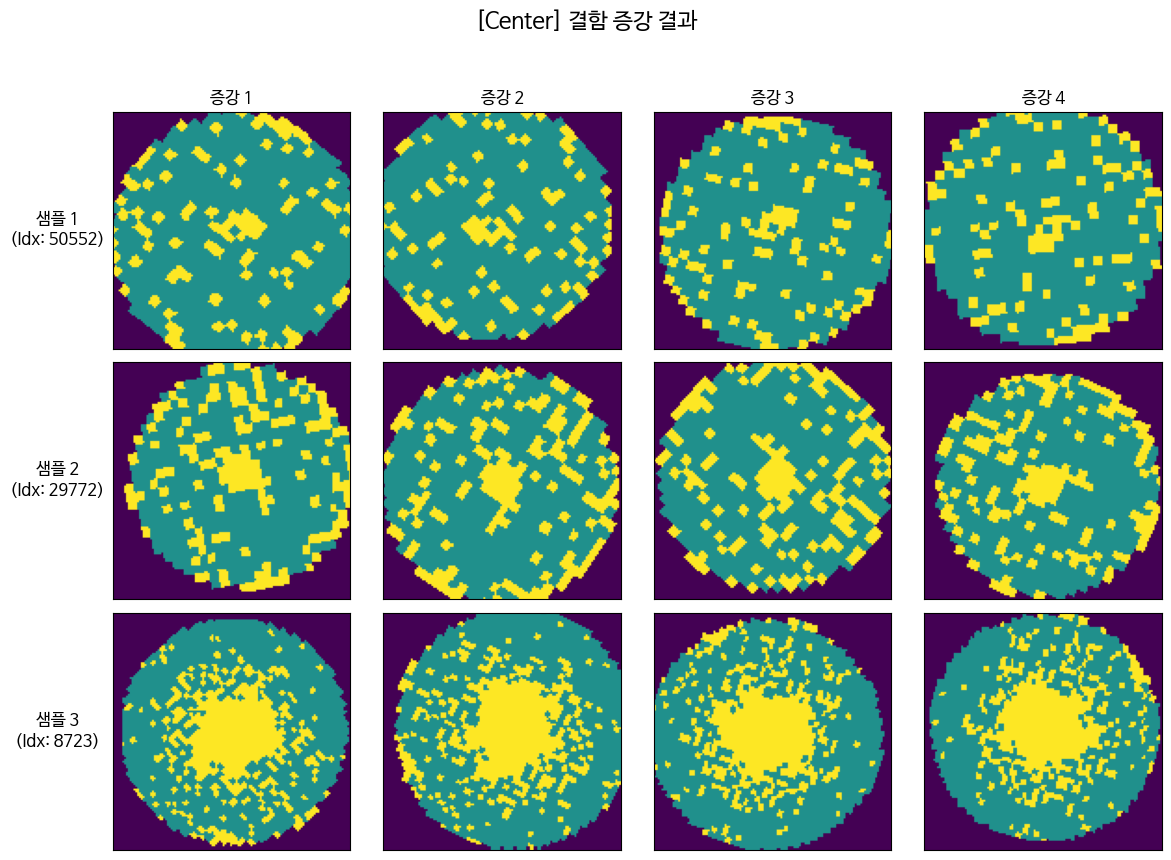

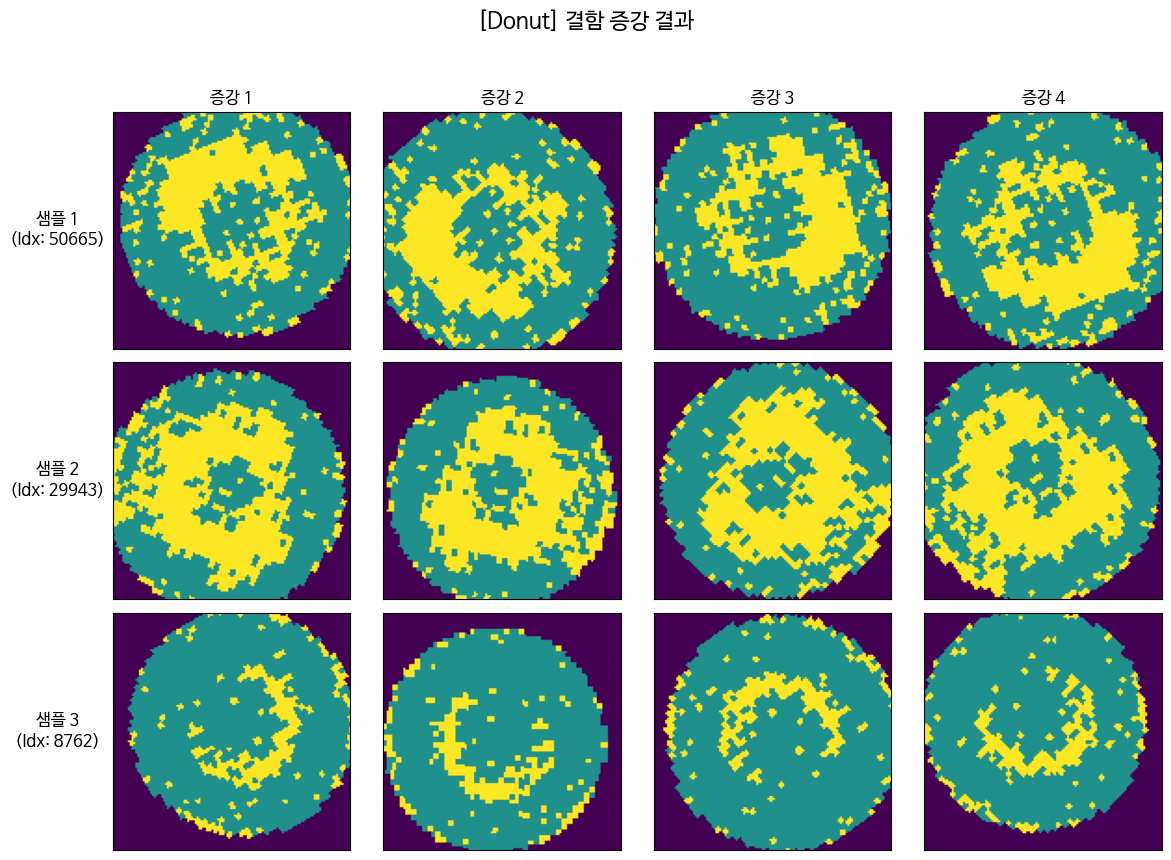

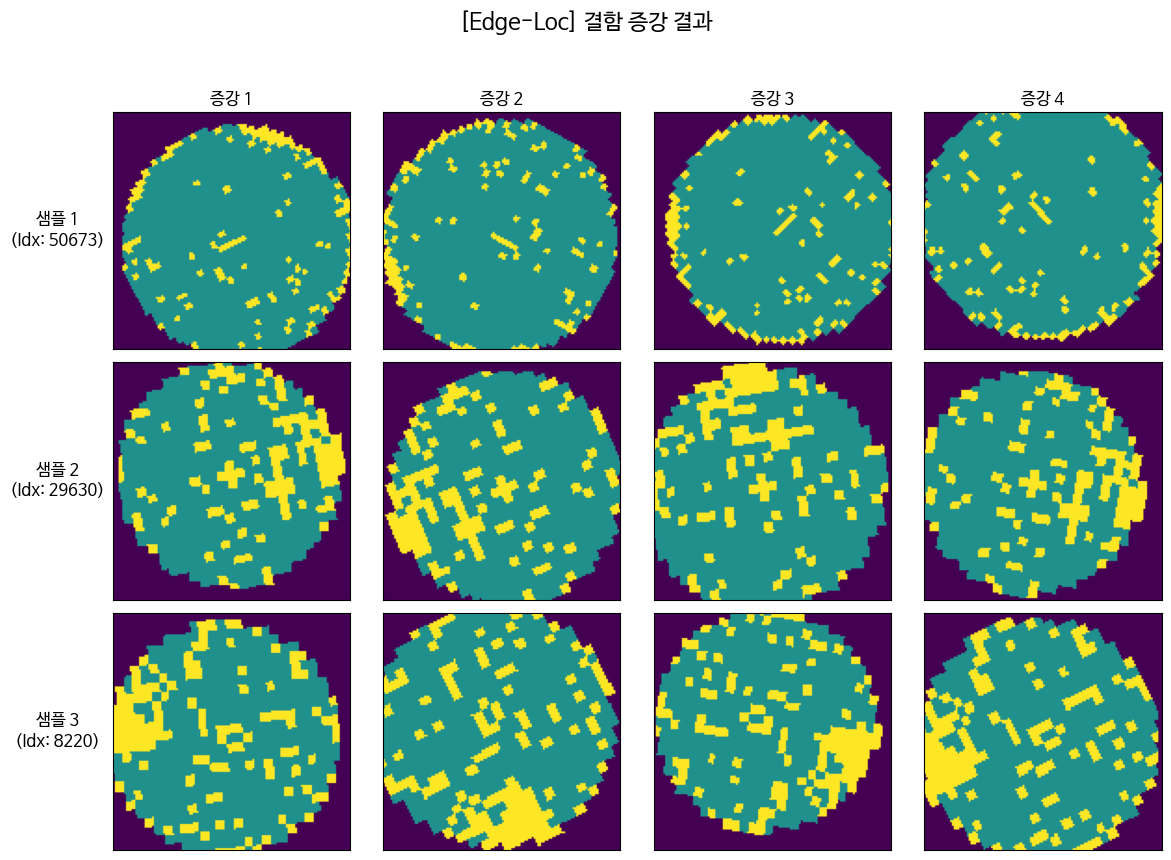

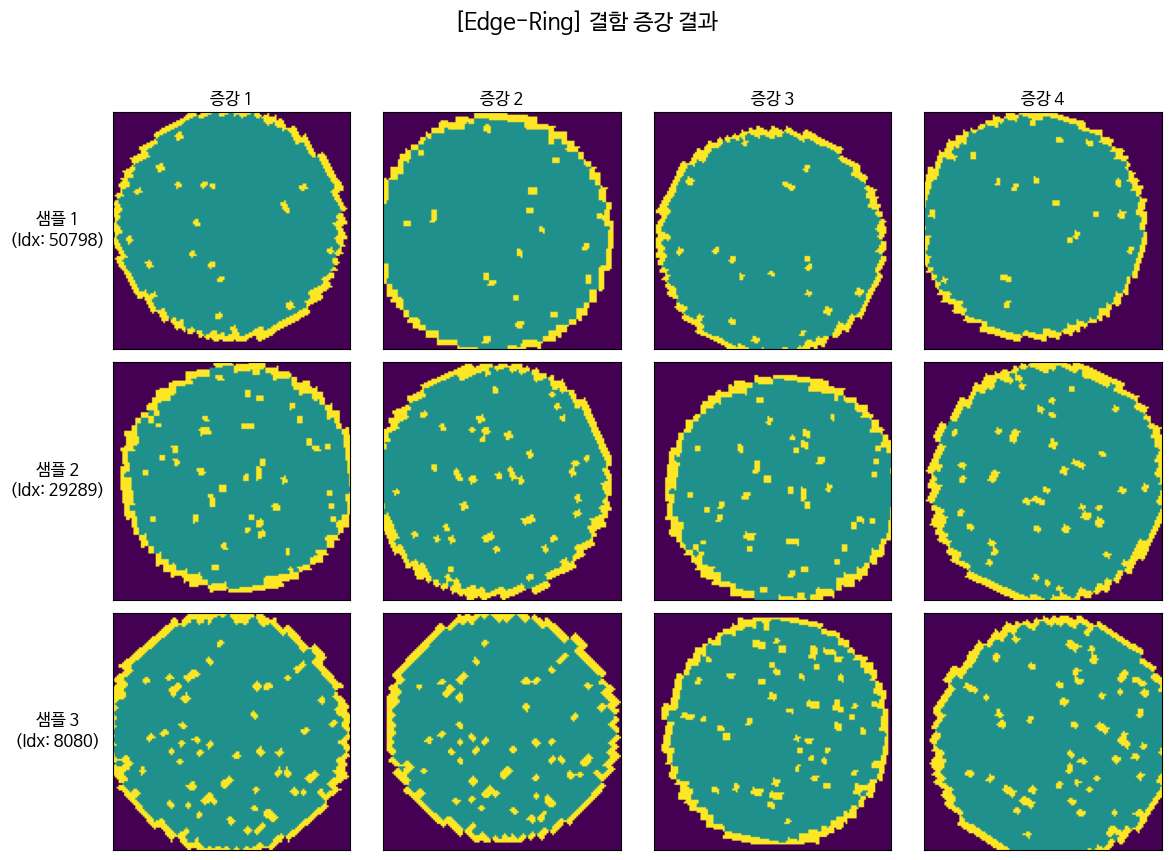

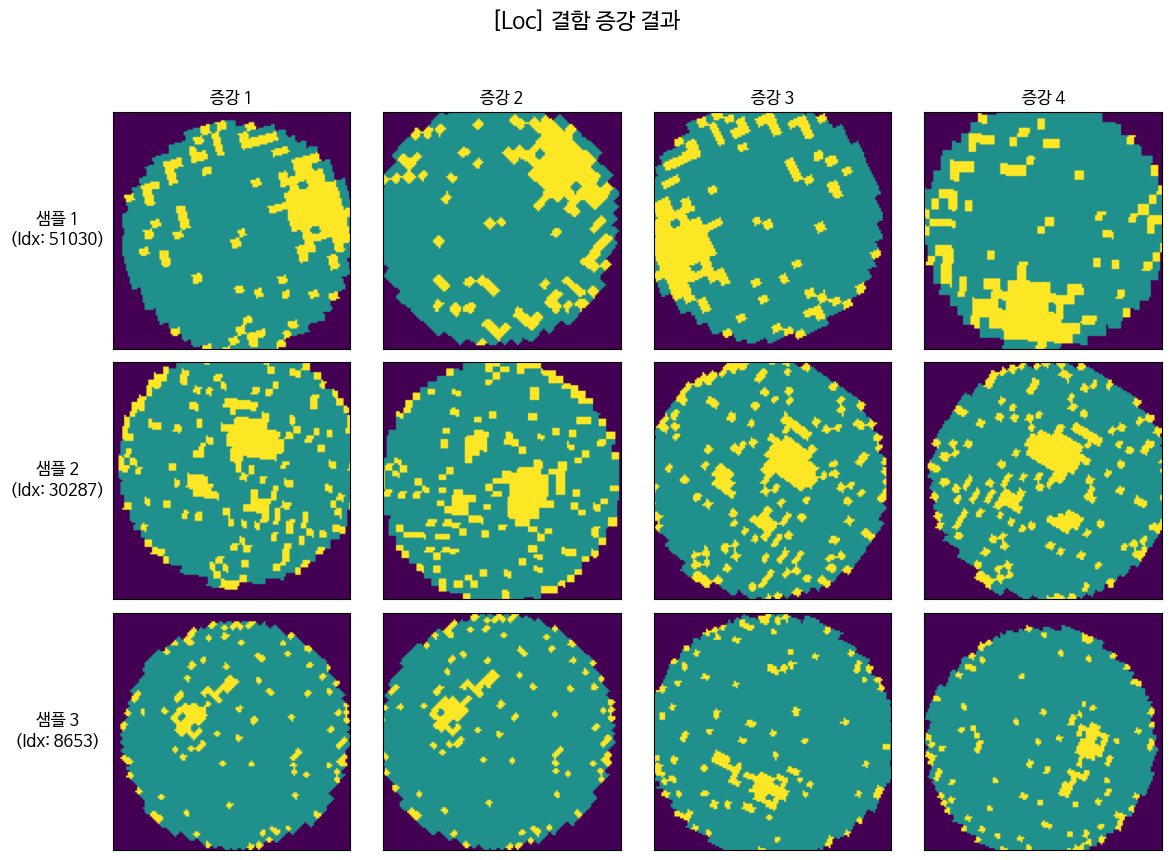

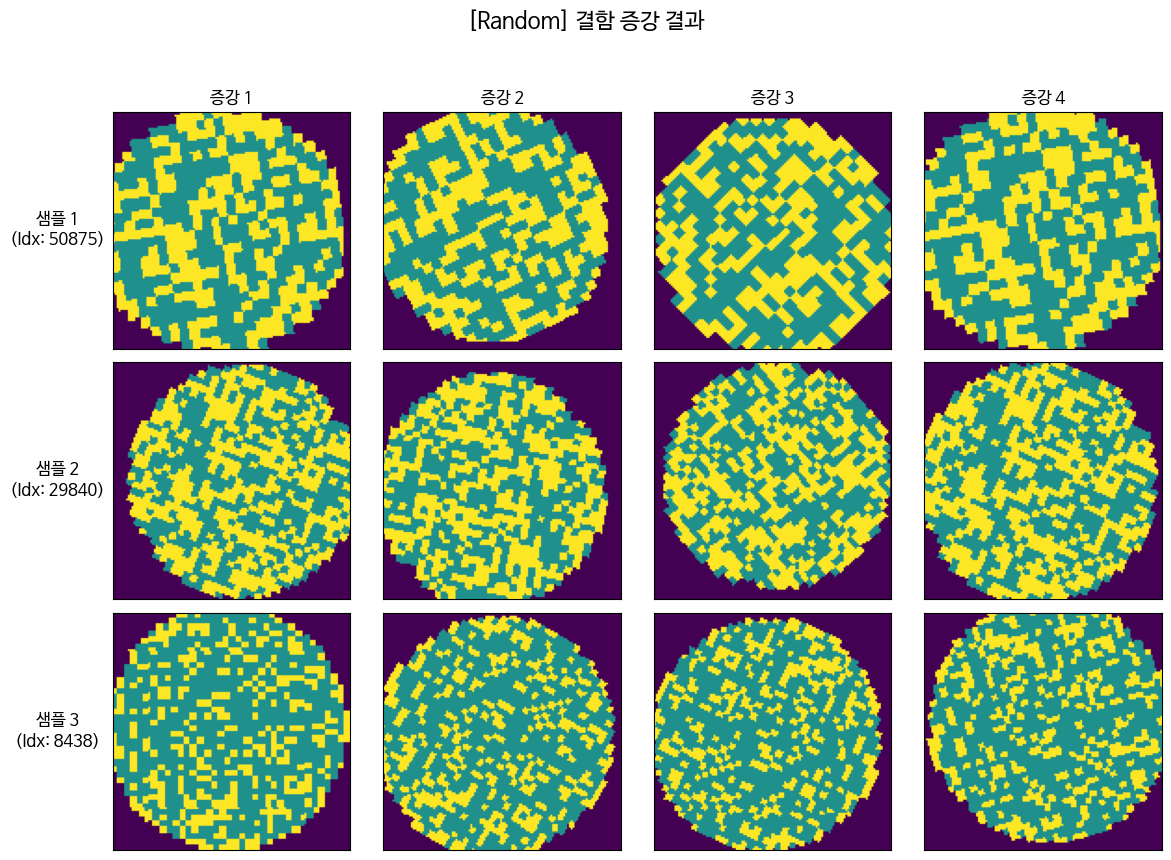

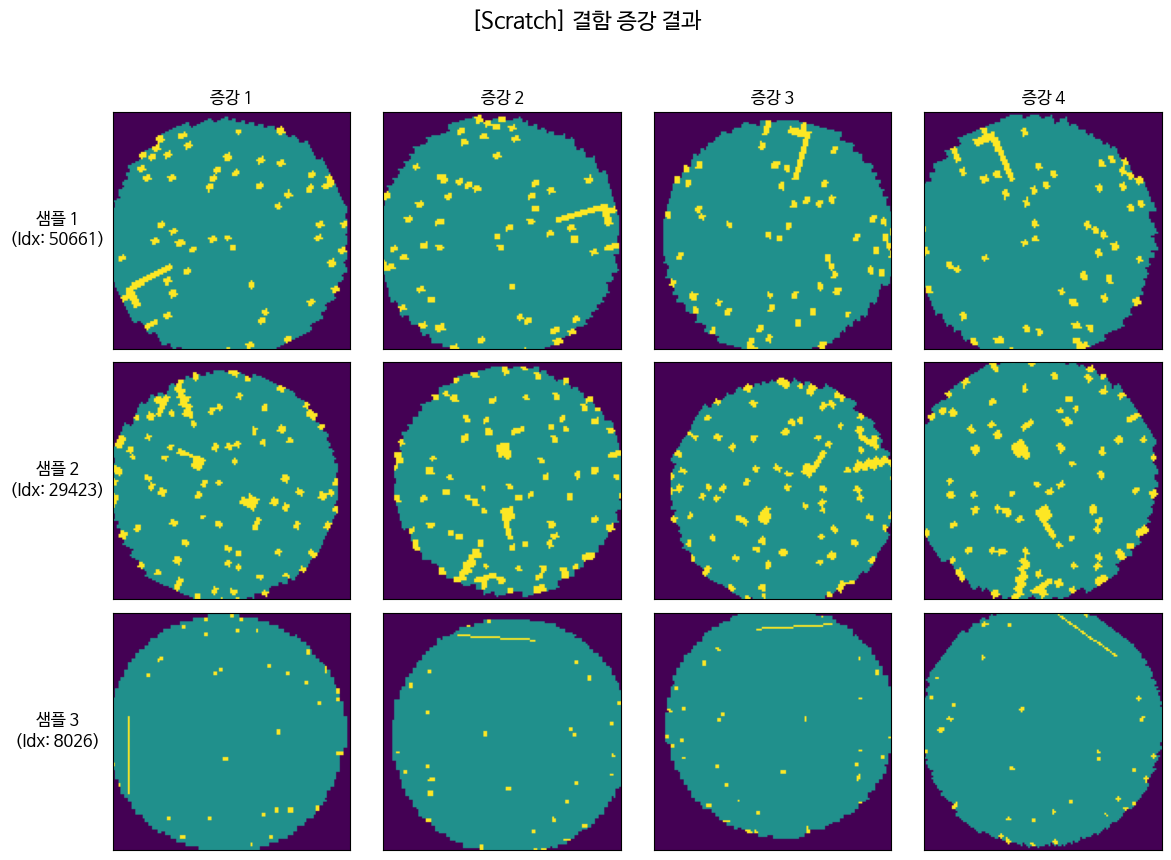

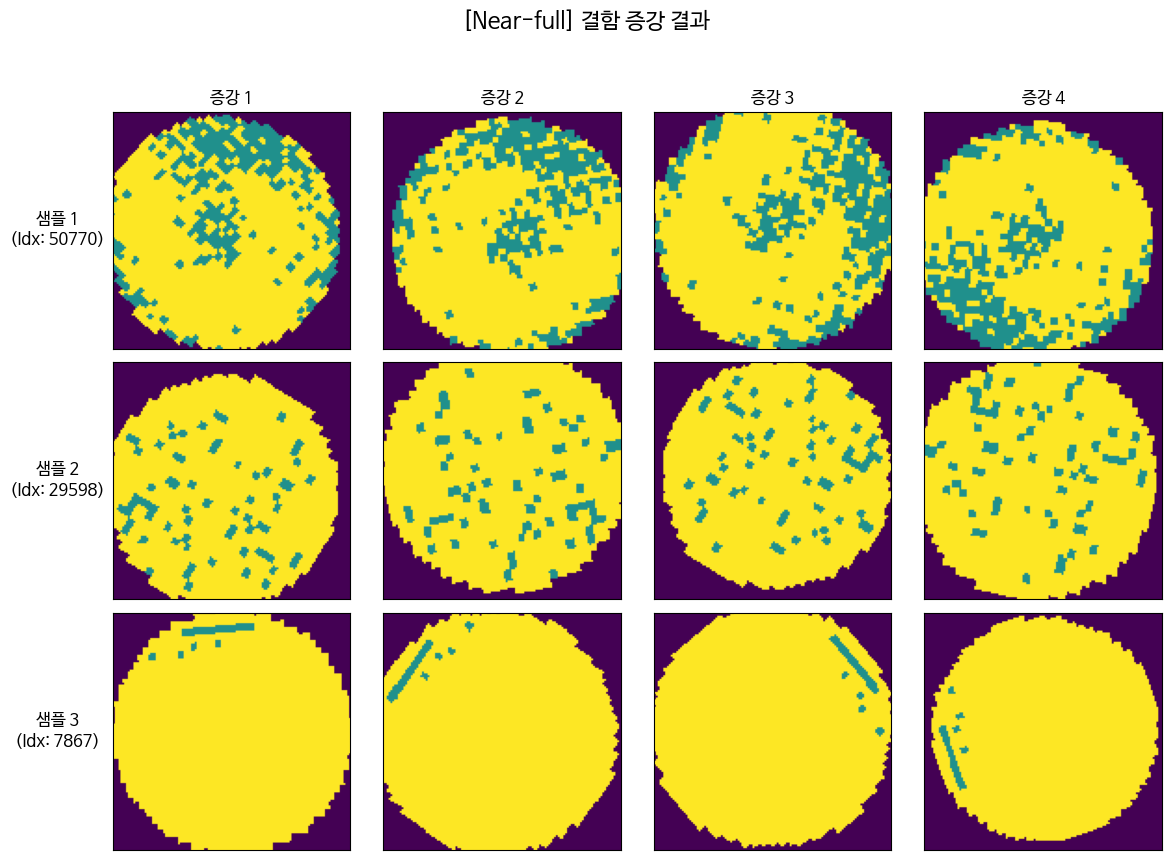


데이터 증강 상세 시각화 검증 완료!


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

print("데이터 증강 파이프라인 무결성 검증 시작...\n")

# ==========================================
# [검증 1] 클래스 균등화 (오버샘플링) 수량 검증
# ==========================================
print("--- [1단계] 훈련 데이터셋 클래스별 분포 검증 ---")
class_counts = train_balanced_df['failureType'].value_counts()
print(class_counts)

# 1. 8개의 '클래스 목록'
expected_classes = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

# 2. 현재 데이터(class_counts)에 누락된 클래스가 있는지 검사
missing_classes = [c for c in expected_classes if c not in class_counts]

# 3. 검증 로직
is_balanced = (not missing_classes) and all(count == dynamic_target_samples for count in class_counts.values)

# 4. 결과 출력
if is_balanced:
    print(f"클래스 오버샘플링 결과: ✅ 정상 (총 8개 클래스 모두 누락 없이 {dynamic_target_samples}개로 균등화 완료)\n")
else:
    if missing_classes:
        print(f"클래스 오버샘플링 결과: ❌ 에러 (누락 발생! 사라진 클래스: {missing_classes})\n")
    else:
        print(f"클래스 오버샘플링 결과: ❌ 에러 (클래스는 다 있으나 수량이 일치하지 않음 - 기대 타겟: {dynamic_target_samples}개)\n")

# ==========================================
# [검증 2] 텐서 규격 및 원핫 인코딩 수치 검증
# ==========================================
print("--- [2단계] 데이터로더 텐서 규격 및 원핫 인코딩 검증 ---")
sample_images, sample_labels = next(iter(train_loader))

# 1) 배치 텐서 Shape 확인
print(f"• 이미지 텐서 Shape: {sample_images.shape} (기대값: [128, 3, 128, 128])")
print(f"• 라벨 텐서 Shape: {sample_labels.shape} (기대값: [128])")

# 2) 원핫 인코딩 채널 합 검증 (모든 픽셀 위치에서 3개 채널의 합은 정확히 1.0이어야 함)
channel_sum = sample_images.sum(dim=1)
is_one_hot_valid = torch.allclose(channel_sum, torch.ones_like(channel_sum))
print(f"3채널 원핫 인코딩 검증: {'✅ 정상 (모든 픽셀 합 1.0 무결성 확보)' if is_one_hot_valid else '❌ 에러 (원핫 오류)'}\n")


# ==========================================
# [검증 3] 실시간 무작위 동적 증강(On-the-fly) 작동 여부 검증
# ==========================================
print("--- [3단계] 실시간 무작위 증강 작동 검증 ---")
# 동일한 인덱스를 두 번 불러왔을 때 증강으로 인해 값이 달라지는지 확인
img_pass1, _ = train_dataset[0]
img_pass2, _ = train_dataset[0]

is_dynamic = not torch.equal(img_pass1, img_pass2)
# 확률적 증강이므로 아주 희박한 확률(운)로 연속으로 동일한 변환이 일어날 수도 있음을 고려하여 메시지 수정
print(f"실시간 무작위 증강 동작 여부: {'✅ 정상 (호출 시마다 무작위 변환 발생)' if is_dynamic else '⚠️ 경고 (증강 미적용이거나, 우연히 동일하게 변환됨)'}\n")


# ==========================================
# [검증 4] 결함 시각화 검증
# ==========================================
print("--- [4단계] 전체 결함 클래스 대상 다중 샘플 증강 시각화 ---")

# 1. 8개의 불량 클래스 목록
expected_classes = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

# 2. 데이터셋의 원본 데이터프레임에서 각 클래스별로 무작위 샘플 3개의 '인덱스(번호)'를 추출합니다.
sample_indices_by_class = {}
dataset_df = train_dataset.df  # Dataset 내부의 데이터프레임 접근

for c in expected_classes:
    # 해당 결함 클래스만 필터링한 뒤, 무작위로 3개를 뽑아 그 인덱스를 저장
    idxs = dataset_df[dataset_df['failureType'] == c].sample(n=3, random_state=42).index.tolist()
    sample_indices_by_class[c] = idxs

# 3. 클래스별로 순회하며 3x4 격자 형태의 시각화 Figure을 8개 생성합니다.
for c in expected_classes:
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))
    fig.suptitle(f"[{c}] 결함 증강 결과", fontsize=16, fontweight='bold')

    # 3개의 샘플(행)을 순회
    for row_idx, data_idx in enumerate(sample_indices_by_class[c]):
        # 4번의 실시간 증강(열)을 순회
        for col_idx in range(4):
            # 인덱스를 호출할 때마다 __getitem__이 실행되며 무작위 증강이 새롭게 적용됨
            augmented_img, _ = train_dataset[data_idx]

            # 3채널 원핫 [3, 128, 128]을 시각화용 2D 이미지 [128, 128]로 복원
            # 0번 채널(배경=0), 1번 채널(정상=1), 2번 채널(결함=2)
            vis_img = (augmented_img[1] * 1 + augmented_img[2] * 2).numpy()

            ax = axes[row_idx, col_idx]
            ax.imshow(vis_img, cmap='viridis')

            # 첫 번째 행에만 열 제목(증강 횟수) 달기
            if row_idx == 0:
                ax.set_title(f"증강 {col_idx+1}", fontsize=12, fontweight='bold')

            # 첫 번째 열에만 행 제목(샘플 번호) 달기
            if col_idx == 0:
                ax.set_ylabel(f"샘플 {row_idx+1}\n(Idx: {data_idx})", fontsize=12, fontweight='bold', rotation=0, labelpad=40, ha='center', va='center')

            # 눈금선 제거
            ax.set_xticks([])
            ax.set_yticks([])

    # 레이아웃 겹치지 않게 자동 조정
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("\n데이터 증강 상세 시각화 검증 완료!")